In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## 傅立葉轉換

1.取像素值 2.計算旋轉因子 3.兩者相乘

In [ ]:
def dft2(image):
    N, M = image.shape
    dft = np.zeros((N, M), dtype=complex)
    for u in range(N):
        for v in range(M):
            sum_value = 0.0
            for x in range(N):
                for y in range(M):
                    angle = -2j * np.pi * ((u * x / N) + (v * y / M))
                    sum_value += image[x, y] * np.exp(angle)
            dft[u, v] = sum_value
    return dft

In [ ]:
def center_shift(frequency_spectrum):
    N, M = frequency_spectrum.shape
    shifted_spectrum = np.zeros_like(frequency_spectrum, dtype=complex)

    # 四個象限交換
    shifted_spectrum[0:N//2, 0:M//2] = frequency_spectrum[N//2:N, M//2:M]
    shifted_spectrum[N//2:N, M//2:M] = frequency_spectrum[0:N//2, 0:M//2]
    shifted_spectrum[0:N//2, M//2:M] = frequency_spectrum[N//2:N, 0:M//2]
    shifted_spectrum[N//2:N, 0:M//2] = frequency_spectrum[0:N//2, M//2:M]

    return shifted_spectrum

## 理想低通濾波器

In [ ]:
def ideal_low_pass_filter(shape, D0):
    N, M = shape
    H = np.zeros((N, M))
    center_x, center_y = N // 2, M // 2
    for u in range(N):
        for v in range(M):
            D_uv = np.sqrt((u - center_x) ** 2 + (v - center_y) ** 2)
            if D_uv <= D0:
                H[u, v] = 1
    return H

## 理想高通濾波器

In [ ]:
def ideal_high_pass_filter(shape, D0):
    N, M = shape
    H = np.ones((N, M))  # 預設全為1
    center_x, center_y = N // 2, M // 2
    for u in range(N):
        for v in range(M):
            D_uv = np.sqrt((u - center_x) ** 2 + (v - center_y) ** 2)
            if D_uv <= D0:
                H[u, v] = 0  # 圓內設為0
    return H

## 逆傅立葉轉換

In [ ]:
#f(x,y) = (1/NM) Σ Σ F(u,v) × e^(+2πj[(ux/N) + (vy/M)])
def idft2(dft):
    N, M = dft.shape
    idft = np.zeros((N, M), dtype=complex)
    for x in range(N):
        for y in range(M):
            sum_value = 0.0
            for u in range(N):
                for v in range(M):
                    angle = 2j * np.pi * ((u * x / N) + (v * y / M))
                    sum_value += dft[u, v] * np.exp(angle)
            idft[x, y] = sum_value / (N * M)
    return np.abs(idft)

## 主程式

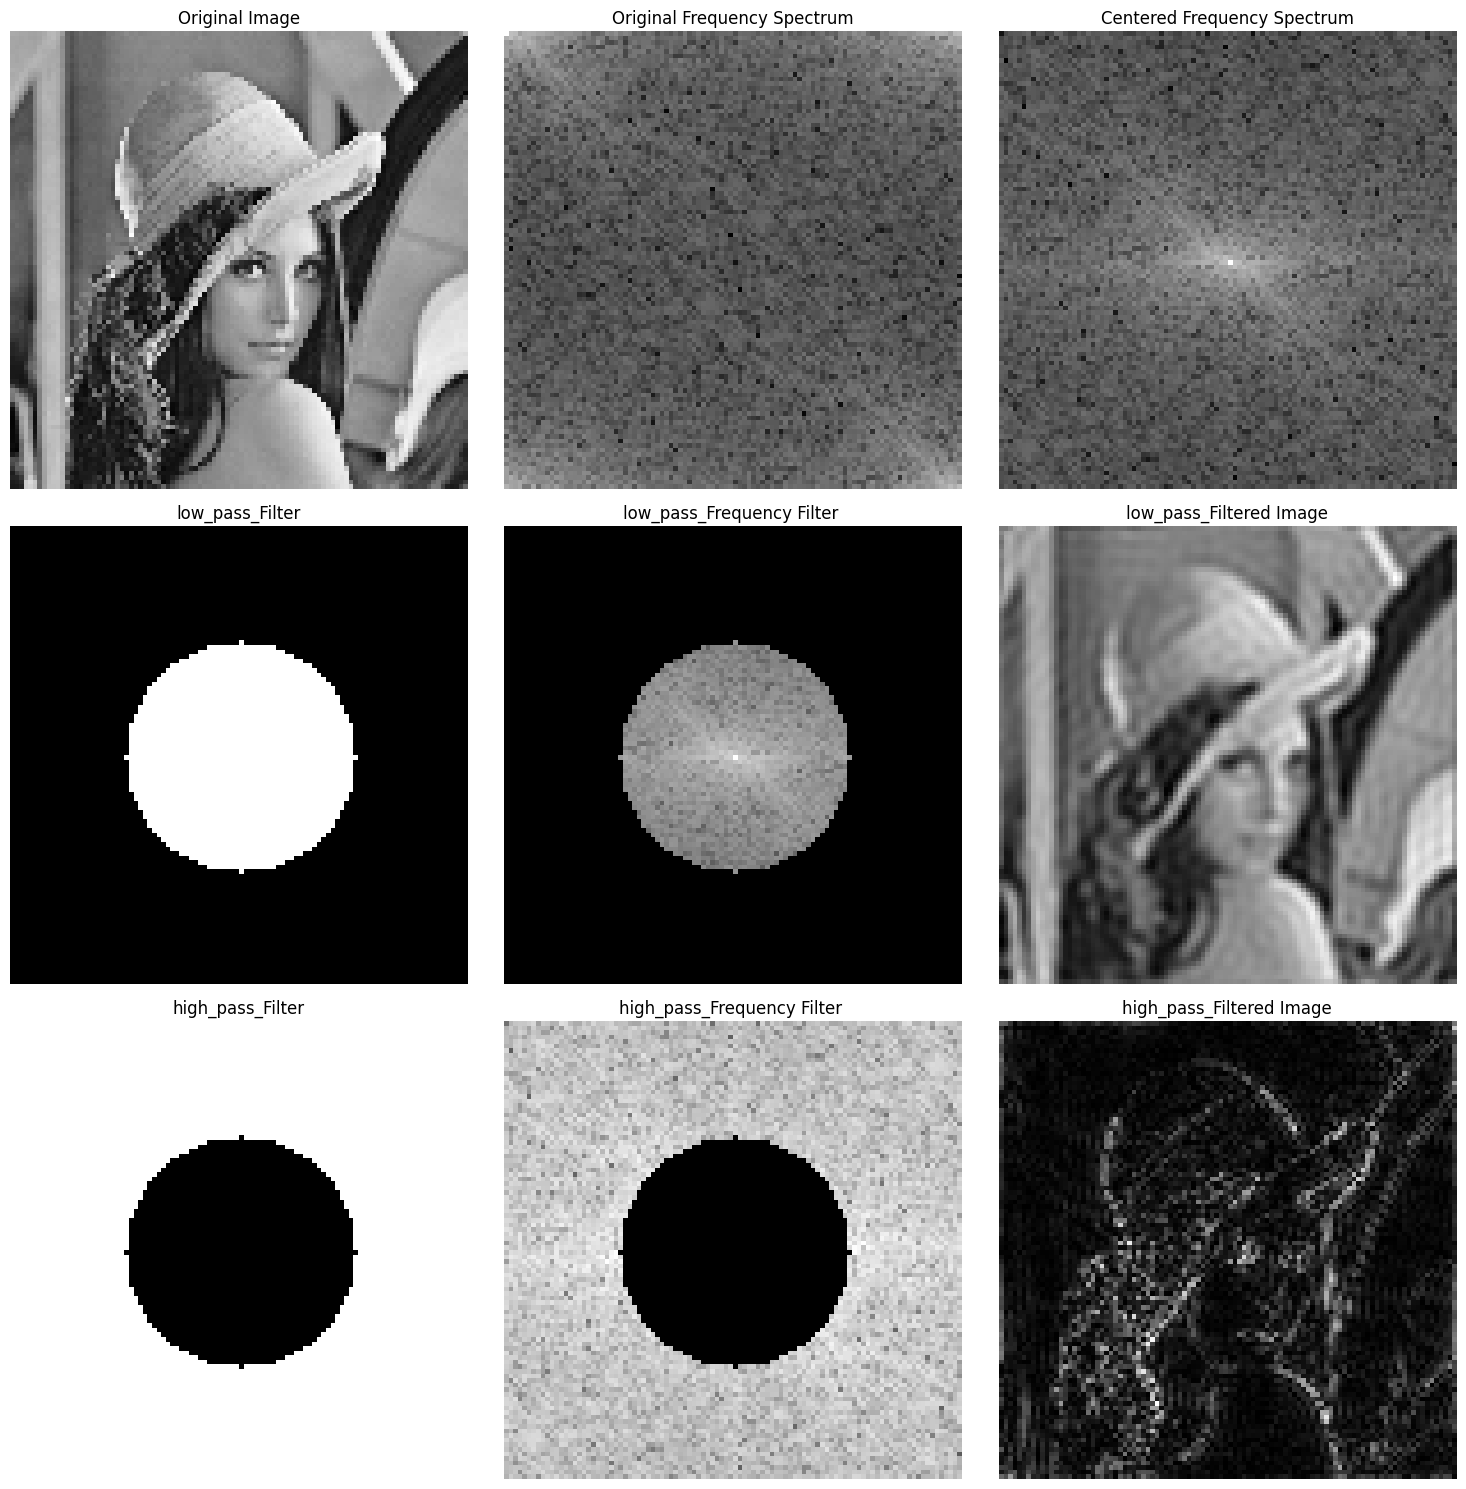

In [ ]:
# 讀取影像
image = cv2.imread("Lenna.png",0)
image = cv2.resize(image,(100,100))

# 設置截止頻率
D0 = 25  # 可以根據影像尺寸和需求進行調整

# 1. 對影像進行傅里葉變換
F_uv = dft2(image)

# 2. 將頻譜平移至中心
centered_F_uv = center_shift(F_uv)

# 3. 生成低通遮罩和高通遮罩，並分別應用到頻譜
low_pass_H_uv = ideal_low_pass_filter(F_uv.shape, D0)
high_pass_H_uv = ideal_high_pass_filter(F_uv.shape, D0)
low_pass_G_uv = low_pass_H_uv * centered_F_uv
high_pass_G_uv = high_pass_H_uv * centered_F_uv

# 4. 進行反傅里葉變換，得到濾波後的影像
low_pass_filtered_image = idft2(low_pass_G_uv)
high_pass_filtered_image = idft2(high_pass_G_uv)

# 顯示結果
plt.figure(figsize=(15, 15))

# 原圖
plt.subplot(3, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# 原始頻譜
plt.subplot(3, 3, 2)
plt.imshow(np.log(np.abs(F_uv) + 1), cmap='gray')
plt.title("Original Frequency Spectrum")
plt.axis('off')

# 中心反轉頻譜
plt.subplot(3, 3, 3)
plt.imshow(np.log(np.abs(centered_F_uv) + 1), cmap='gray')
plt.title("Centered Frequency Spectrum")
plt.axis('off')

# 原始遮罩
plt.subplot(3, 3, 4)
plt.imshow(low_pass_H_uv, cmap='gray')
plt.title('low_pass_Filter')
plt.axis('off')

# 頻譜遮罩
plt.subplot(3, 3, 5)
plt.imshow(np.log(1 + np.abs(low_pass_G_uv)), cmap='gray')
plt.title('low_pass_Frequency Filter ')
plt.axis('off')

# 結果
plt.subplot(3, 3, 6)
plt.imshow(low_pass_filtered_image, cmap='gray')
plt.title('low_pass_Filtered Image')
plt.axis('off')

# 原始遮罩
plt.subplot(3, 3, 7)
plt.imshow(high_pass_H_uv, cmap='gray')
plt.title('high_pass_Filter')
plt.axis('off')

# 頻譜遮罩
plt.subplot(3, 3, 8)
plt.imshow(np.log(1 + np.abs(high_pass_G_uv)), cmap='gray')
plt.title('high_pass_Frequency Filter ')
plt.axis('off')

# 結果
plt.subplot(3, 3, 9)
plt.imshow(high_pass_filtered_image, cmap='gray')
plt.title('high_pass_Filtered Image')
plt.axis('off')

plt.tight_layout()
plt.show()


## Numpy提供的套件(時間複雜度大幅降低)

In [ ]:
#使用 NumPy 的 2D FFT
def fft2_numpy(image):
    return np.fft.fft2(image)

#使用 NumPy 的 2D IFFT
def ifft2_numpy(spectrum):
    return np.fft.ifft2(spectrum).real

#將頻譜中心化（NumPy 內建）
def fftshift(spectrum):
    return np.fft.fftshift(spectrum)

#反中心化（濾波後需要）
def ifftshift(spectrum):
    return np.fft.ifftshift(spectrum)